## Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import box

## Locate the project and files

In [2]:
project_root = Path.cwd().resolve()

# Move upward until the project data folder is found.
while project_root != project_root.parent:
    if (project_root / "data").exists():
        break
    project_root = project_root.parent

fires_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_fires_2005_2025_clean.parquet"
)

boundary_path = (
    project_root
    / "data"
    / "raw"
    / "boundaries"
    / "manitoba_provincial_boundary.geojson"
)

print("Current directory:", Path.cwd())
print("Project root:", project_root)
print("Fire file found:", fires_path.exists())
print("Boundary file found:", boundary_path.exists())

Current directory: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/notebooks
Project root: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence
Fire file found: True
Boundary file found: True


## Load the data

In [3]:
fires = gpd.read_parquet(fires_path)
manitoba_boundary = gpd.read_file(boundary_path)

fires = fires.loc[
    fires["SPATIAL_STATUS"] == "Inside Manitoba"
].copy()

print("Fire records:", len(fires))
print("Fire CRS:", fires.crs.to_epsg())
print("Boundary CRS:", manitoba_boundary.crs.to_epsg())

Fire records: 7915
Fire CRS: 4326
Boundary CRS: 4326


## Project into metres

In [4]:
TARGET_CRS = "EPSG:3347"

fires_projected = fires.to_crs(TARGET_CRS)
boundary_projected = manitoba_boundary.to_crs(TARGET_CRS)

manitoba_geometry = boundary_projected.geometry.union_all()

print("Projected fire CRS:", fires_projected.crs.to_epsg())
print("Projected boundary CRS:", boundary_projected.crs.to_epsg())

Projected fire CRS: 3347
Projected boundary CRS: 3347


## Create the complete 10-km grid

In [5]:
GRID_SIZE_M = 10_000

min_x, min_y, max_x, max_y = boundary_projected.total_bounds

# Align grid boundaries to exact 10-km coordinates.
origin_x = np.floor(min_x / GRID_SIZE_M) * GRID_SIZE_M
origin_y = np.floor(min_y / GRID_SIZE_M) * GRID_SIZE_M

aligned_max_x = np.ceil(max_x / GRID_SIZE_M) * GRID_SIZE_M
aligned_max_y = np.ceil(max_y / GRID_SIZE_M) * GRID_SIZE_M

x_values = np.arange(origin_x, aligned_max_x, GRID_SIZE_M)
y_values = np.arange(origin_y, aligned_max_y, GRID_SIZE_M)

grid_records = []

for column, x in enumerate(x_values):
    for row, y in enumerate(y_values):
        grid_records.append(
            {
                "GRID_ID": f"MB_{row:03d}_{column:03d}",
                "ROW": row,
                "COLUMN": column,
                "geometry": box(
                    x,
                    y,
                    x + GRID_SIZE_M,
                    y + GRID_SIZE_M,
                ),
            }
        )

complete_grid = gpd.GeoDataFrame(
    grid_records,
    geometry="geometry",
    crs=TARGET_CRS,
)

print("Complete bounding-box grid cells:", len(complete_grid))

Complete bounding-box grid cells: 11000


## Keep cells intersecting Manitoba

In [6]:
manitoba_grid = complete_grid.loc[
    complete_grid.intersects(manitoba_geometry)
].copy()

manitoba_grid.reset_index(drop=True, inplace=True)

print("Cells intersecting Manitoba:", len(manitoba_grid))

Cells intersecting Manitoba: 6501


## Calculate Manitoba coverage per cell

In [7]:
CELL_AREA_KM2 = GRID_SIZE_M**2 / 1_000_000

manitoba_grid["MB_AREA_KM2"] = (
    manitoba_grid.geometry
    .intersection(manitoba_geometry)
    .area
    / 1_000_000
)

manitoba_grid["MB_COVERAGE_PCT"] = (
    manitoba_grid["MB_AREA_KM2"]
    / CELL_AREA_KM2
    * 100
)

display(
    manitoba_grid[
        ["MB_AREA_KM2", "MB_COVERAGE_PCT"]
    ].describe()
)

,MB_AREA_KM2,MB_COVERAGE_PCT
count,6501.000000,6501.000000
mean,96.585695,96.585695
std,15.375247,15.375247
min,0.001117,0.001117
25%,100.000000,100.000000
50%,100.000000,100.000000
75%,100.000000,100.000000
max,100.000000,100.000000


## Assign each fire to a grid cell

In [8]:
fires_projected["COLUMN"] = np.floor(
    (fires_projected.geometry.x - origin_x)
    / GRID_SIZE_M
).astype(int)

fires_projected["ROW"] = np.floor(
    (fires_projected.geometry.y - origin_y)
    / GRID_SIZE_M
).astype(int)

fires_projected["GRID_ID"] = (
    "MB_"
    + fires_projected["ROW"].astype(str).str.zfill(3)
    + "_"
    + fires_projected["COLUMN"].astype(str).str.zfill(3)
)

valid_grid_ids = set(manitoba_grid["GRID_ID"])

unmatched_mask = ~fires_projected["GRID_ID"].isin(
    valid_grid_ids
)

print("Fire records assigned:", (~unmatched_mask).sum())
print("Unmatched fire records:", unmatched_mask.sum())

Fire records assigned: 7915
Unmatched fire records: 0


## Count fires in each grid cell

In [9]:
fire_counts = (
    fires_projected
    .groupby("GRID_ID")
    .size()
    .rename("FIRE_COUNT_2005_2025")
)

manitoba_grid["FIRE_COUNT_2005_2025"] = (
    manitoba_grid["GRID_ID"]
    .map(fire_counts)
    .fillna(0)
    .astype(int)
)

print(
    "Cells containing at least one fire:",
    (manitoba_grid["FIRE_COUNT_2005_2025"] > 0).sum(),
)

print(
    "Maximum fires in one cell:",
    manitoba_grid["FIRE_COUNT_2005_2025"].max(),
)

print(
    "Total fires counted:",
    manitoba_grid["FIRE_COUNT_2005_2025"].sum(),
)

Cells containing at least one fire: 2593
Maximum fires in one cell: 140
Total fires counted: 7915


## Map historical fire counts

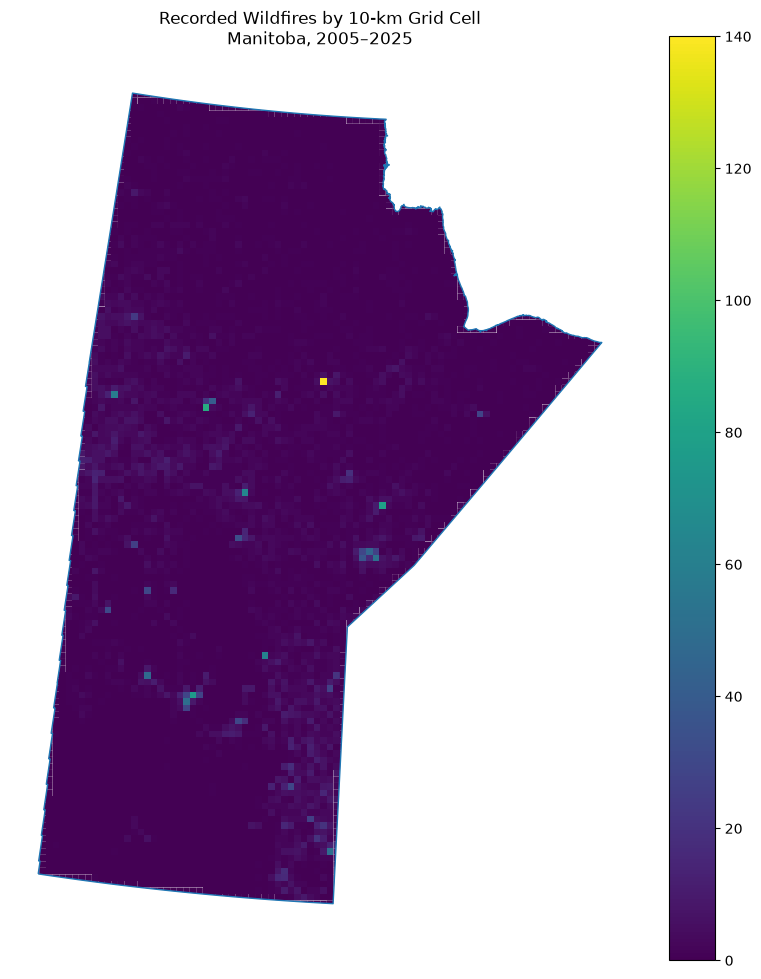

In [10]:
grid_for_display = manitoba_grid.copy()

# Clip border cells to Manitoba for display only.
grid_for_display["geometry"] = (
    grid_for_display.geometry
    .intersection(manitoba_geometry)
)

fig, ax = plt.subplots(figsize=(10, 12))

grid_for_display.plot(
    ax=ax,
    column="FIRE_COUNT_2005_2025",
    legend=True,
    linewidth=0.15,
)

boundary_projected.boundary.plot(
    ax=ax,
    linewidth=1,
)

ax.set_title(
    "Recorded Wildfires by 10-km Grid Cell\n"
    "Manitoba, 2005–2025"
)

ax.set_axis_off()

plt.show()

## Save the grid and assigned fires

In [11]:
grid_output_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_grid_10km.parquet"
)

fires_output_path = (
    project_root
    / "data"
    / "interim"
    / "manitoba_fires_with_grid_2005_2025.parquet"
)

manitoba_grid.to_parquet(
    grid_output_path,
    index=False,
)

fires_projected.to_parquet(
    fires_output_path,
    index=False,
)

print("Grid saved:", grid_output_path)
print("Grid file exists:", grid_output_path.exists())

print("\nFires saved:", fires_output_path)
print("Fire file exists:", fires_output_path.exists())

Grid saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/data/interim/manitoba_grid_10km.parquet
Grid file exists: True

Fires saved: /Users/eleazar/Documents/manitoba-wildfire-risk-intelligence/data/interim/manitoba_fires_with_grid_2005_2025.parquet
Fire file exists: True


## Inspect the busiest cells

In [12]:
top_cells = (
    manitoba_grid
    .nlargest(10, "FIRE_COUNT_2005_2025")
    [
        [
            "GRID_ID",
            "ROW",
            "COLUMN",
            "MB_AREA_KM2",
            "MB_COVERAGE_PCT",
            "FIRE_COUNT_2005_2025",
        ]
    ]
)

display(top_cells)

,GRID_ID,ROW,COLUMN,MB_AREA_KM2,MB_COVERAGE_PCT,FIRE_COUNT_2005_2025
4652,MB_080_044,80,44,100.0,100.0,140
2450,MB_076_026,76,26,100.0,100.0,87
5442,MB_061_053,61,53,100.0,100.0,79
2160,MB_032_024,32,24,100.0,100.0,75
3171,MB_063_032,63,32,100.0,100.0,65
3512,MB_038_035,38,35,100.0,100.0,61
759,MB_078_012,78,12,100.0,100.0,59
5360,MB_053_052,53,52,100.0,100.0,51
2037,MB_031_023,31,23,100.0,100.0,50
4702,MB_008_045,8,45,100.0,100.0,50


In [13]:
top_grid_id = top_cells.iloc[0]["GRID_ID"]

top_cell_fires = fires_projected.loc[
    fires_projected["GRID_ID"] == top_grid_id
].copy()

print("Top grid cell:", top_grid_id)
print("Number of fires:", len(top_cell_fires))
print(
    "Unique coordinate locations:",
    len(
        top_cell_fires[
            ["LATITUDE", "LONGITUDE"]
        ].drop_duplicates()
    ),
)

print("\nFires by cause:")
display(
    top_cell_fires["CAUSE_LABEL"]
    .value_counts()
    .rename("fire_count")
    .to_frame()
)

print("\nFires by year:")
display(
    top_cell_fires
    .groupby("YEAR")
    .size()
    .rename("fire_count")
    .to_frame()
)

Top grid cell: MB_080_044
Number of fires: 140
Unique coordinate locations: 130

Fires by cause:


,fire_count
CAUSE_LABEL,
Human,136
Natural,4



Fires by year:


,fire_count
YEAR,
2005,5
2006,17
2007,6
2008,11
2010,10
2011,12
2012,11
2013,15
2014,11


In [14]:
coordinate_frequency = (
    top_cell_fires
    .groupby(["LATITUDE", "LONGITUDE"])
    .size()
    .sort_values(ascending=False)
    .rename("fire_count")
)

display(coordinate_frequency.head(10).to_frame())

,,fire_count
LATITUDE,LONGITUDE,
56.252778,-96.142778,3
56.253611,-96.138056,2
56.252778,-96.143333,2
56.253611,-96.138611,2
56.256944,-96.142500,2
56.252500,-96.143889,2
56.253333,-96.138611,2
56.245556,-96.143056,2
56.253333,-96.139167,2


## Map 

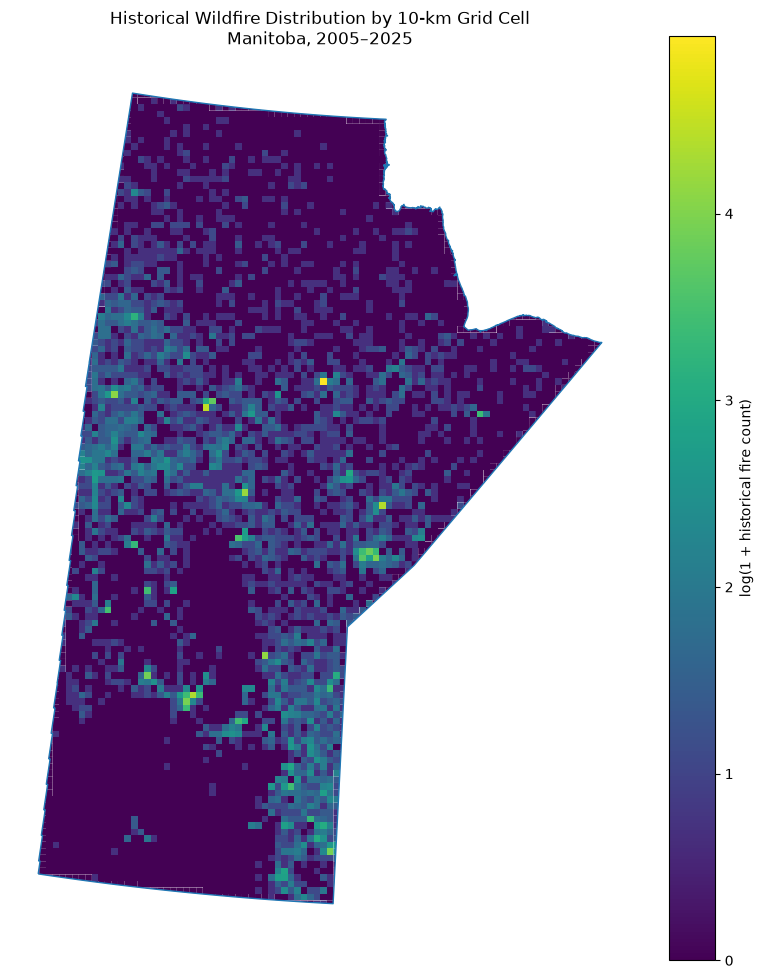

In [15]:
grid_for_display["LOG_FIRE_COUNT"] = np.log1p(
    grid_for_display["FIRE_COUNT_2005_2025"]
)

fig, ax = plt.subplots(figsize=(10, 12))

grid_for_display.plot(
    ax=ax,
    column="LOG_FIRE_COUNT",
    legend=True,
    linewidth=0.15,
    legend_kwds={
        "label": "log(1 + historical fire count)",
    },
)

boundary_projected.boundary.plot(
    ax=ax,
    linewidth=1,
)

ax.set_title(
    "Historical Wildfire Distribution by 10-km Grid Cell\n"
    "Manitoba, 2005–2025"
)

ax.set_axis_off()

plt.show()

log1p reduces the visual dominance of the largest hotspot so lower-count patterns become visible. It changes only the visualization—not the actual fire counts.